In [1]:
import pandas as pd

In [2]:
#data 읽어들이기(5년)
for i in range(5):
    df = pd.read_csv(f'{2015 + i}.csv', sep = ',', header = 0, engine = 'python')
    if i == 0:
        df2015 = df
    elif i == 1:
        df2016 = df
    elif i == 2:
        df2017 = df
    elif i == 3:
        df2018 = df
    elif i == 4:
        df2019 = df

In [3]:
#확인 및 전처리
df2015c = df2015.copy()
df2016c = df2016.copy()
df2017c = df2017.copy()
df2018c = df2018.copy()
df2019c = df2019.copy()

df2015c.columns = df2015c.columns.str.replace(' ', '_')
df2016c.columns = df2016c.columns.str.replace(' ', '_')
df2017c.columns = df2017c.columns.str.replace('.', '_')
df2018c.columns = df2018c.columns.str.replace(' ', '_')
df2019c.columns = df2019c.columns.str.replace(' ', '_')

df2018c['Country'] = df2018c['Country_or_region']
df2019c['Country'] = df2019c['Country_or_region']

df2018c['Happiness_Score'] = df2018c['Score']
df2019c['Happiness_Score'] = df2019c['Score']

df2015c['GDP_per_Capita'] = df2015c['Economy_(GDP_per_Capita)']
df2016c['GDP_per_Capita'] = df2016c['Economy_(GDP_per_Capita)']
df2017c['GDP_per_Capita'] = df2017c['Economy__GDP_per_Capita_']
df2018c['GDP_per_Capita'] = df2018c['GDP_per_capita']
df2019c['GDP_per_Capita'] = df2019c['GDP_per_capita']

df2018c['Happiness_Rank'] = df2018c['Overall_rank']
df2019c['Happiness_Rank'] = df2019c['Overall_rank']

df2015c['Health'] = df2015c['Health_(Life_Expectancy)']
df2016c['Health'] = df2016c['Health_(Life_Expectancy)']
df2017c['Health'] = df2017c['Health__Life_Expectancy_']
df2018c['Health'] = df2018c['Healthy_life_expectancy']
df2019c['Health'] = df2019c['Healthy_life_expectancy']

df2018c['Freedom'] = df2018c['Freedom_to_make_life_choices']
df2019c['Freedom'] = df2019c['Freedom_to_make_life_choices']

df2015c['Trust'] = df2015c['Trust_(Government_Corruption)']
df2016c['Trust'] = df2016c['Trust_(Government_Corruption)']
df2017c['Trust'] = df2017c['Trust__Government_Corruption_']
df2018c['Trust'] = df2018c['Perceptions_of_corruption']
df2019c['Trust'] = df2019c['Perceptions_of_corruption']

#데이터프레임화
df2015c2 = pd.DataFrame([df2015c['Country'], df2015c['Happiness_Rank'], df2015c['Happiness_Score'], df2015c['GDP_per_Capita'], df2015c['Health'], df2015c['Freedom'], df2015c['Trust'], df2015c['Generosity']],
                        index = ['Country', 'Happiness_Rank', 'Happiness_Score', 'GDP_per_Capita', 'Health', 'Freedom', 'Trust', 'Generosity'])
df2015c2 = df2015c2.T
df2016c2 = pd.DataFrame([df2016c['Country'], df2016c['Happiness_Rank'], df2016c['Happiness_Score'], df2016c['GDP_per_Capita'], df2016c['Health'], df2016c['Freedom'], df2016c['Trust'], df2016c['Generosity']],
                        index = ['Country', 'Happiness_Rank', 'Happiness_Score', 'GDP_per_Capita', 'Health', 'Freedom', 'Trust', 'Generosity'])
df2016c2 = df2016c2.T
df2017c2 = pd.DataFrame([df2017c['Country'], df2017c['Happiness_Rank'], df2017c['Happiness_Score'], df2017c['GDP_per_Capita'], df2017c['Health'], df2017c['Freedom'], df2017c['Trust'], df2017c['Generosity']],
                        index = ['Country', 'Happiness_Rank', 'Happiness_Score', 'GDP_per_Capita', 'Health', 'Freedom', 'Trust', 'Generosity'])
df2017c2 = df2017c2.T
df2018c2 = pd.DataFrame([df2018c['Country'], df2018c['Happiness_Rank'], df2018c['Happiness_Score'], df2018c['GDP_per_Capita'], df2018c['Health'], df2018c['Freedom'], df2018c['Trust'], df2018c['Generosity']],
                        index = ['Country', 'Happiness_Rank', 'Happiness_Score', 'GDP_per_Capita', 'Health', 'Freedom', 'Trust', 'Generosity'])
df2018c2 = df2018c2.T
df2019c2 = pd.DataFrame([df2019c['Country'], df2019c['Happiness_Rank'], df2019c['Happiness_Score'], df2019c['GDP_per_Capita'], df2019c['Health'], df2019c['Freedom'], df2019c['Trust'], df2019c['Generosity']],
                        index = ['Country', 'Happiness_Rank', 'Happiness_Score', 'GDP_per_Capita', 'Health', 'Freedom', 'Trust', 'Generosity'])
df2019c2 = df2019c2.T

#모든 데이터프레임에 'Year' 컬럼 추가 및 통합
df2015c2['Year'] = 2015
df2016c2['Year'] = 2016
df2017c2['Year'] = 2017
df2018c2['Year'] = 2018
df2019c2['Year'] = 2019

df_all = pd.concat([df2015c2, df2016c2, df2017c2, df2018c2, df2019c2])

#데이터 타입 숫자형으로 변환 (전처리 시 Object로 변할 수 있음)
cols = ['Happiness_Score', 'GDP_per_Capita', 'Freedom', 'Trust']
df_all[cols] = df_all[cols].apply(pd.to_numeric, errors='coerce')

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [5]:
#1) 어느 나라가 행복지수가 오랫동안(5년 평균) 높았나?
avg_happiness = df_all.groupby('Country')['Happiness_Score'].mean().sort_values(ascending=False).head(10)

#2) 상관관계 분석
corr_gdp = df_all['Happiness_Score'].corr(df_all['GDP_per_Capita'])
corr_freedom = df_all['Happiness_Score'].corr(df_all['Freedom'])
corr_trust = df_all['Happiness_Score'].corr(df_all['Trust'])

print("--- 5년 평균 행복지수 상위 10개국 ---")
print(avg_happiness)
print(f"\n행복지수와 GDP 상관관계: {corr_gdp:.4f}") #행복지수와 GDP 상관관계: 0.7893 -> 강력한 상관관계
print(f"행복지수와 자유도 상관관계: {corr_freedom:.4f}") #행복지수와 자유도 상관관계: 0.5513 -> 상관관계
print(f"행복지수와 부패인식(신뢰) 상관관계: {corr_trust:.4f}") #행복지수와 부패인식(신뢰) 상관관계: 0.3984 ->약한 상관관계

--- 5년 평균 행복지수 상위 10개국 ---
Country
Denmark        7.5460
Norway         7.5410
Finland        7.5378
Switzerland    7.5114
Iceland        7.5110
Netherlands    7.4046
Canada         7.3506
Sweden         7.3192
New Zealand    7.3130
Australia      7.2762
Name: Happiness_Score, dtype: float64

행복지수와 GDP 상관관계: 0.7893
행복지수와 자유도 상관관계: 0.5513
행복지수와 부패인식(신뢰) 상관관계: 0.3984


#### 상관관계 히트맵

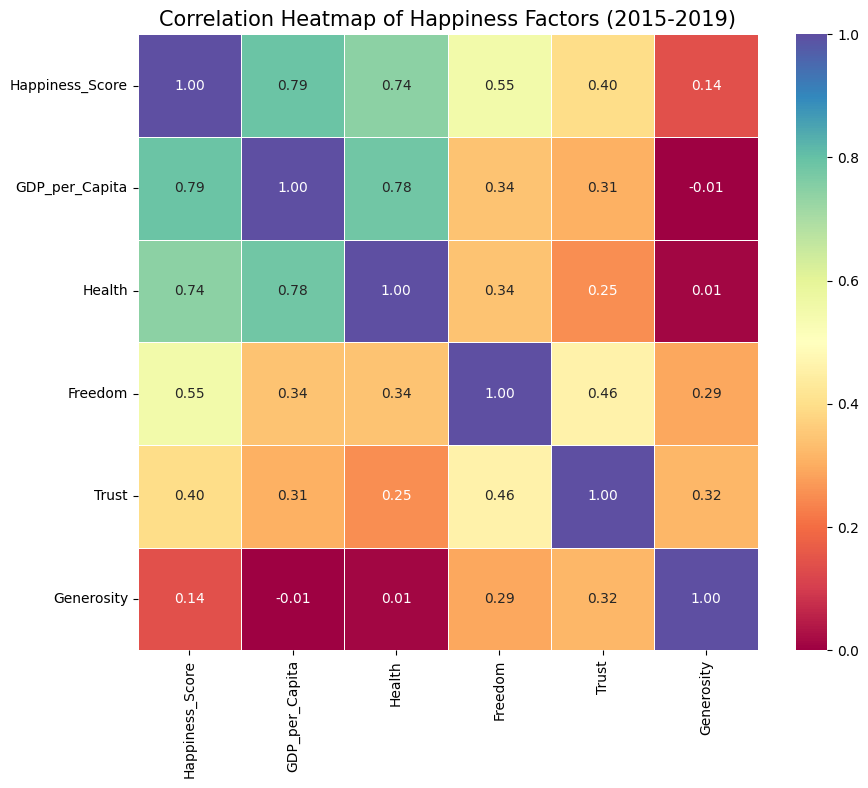

In [12]:
#상관계수 행렬 계산
cols_to_view = ['Happiness_Score', 'GDP_per_Capita', 'Health', 'Freedom', 'Trust', 'Generosity']
corr_matrix = df_all[cols_to_view].corr()

# 히트맵 그래프
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,      # 칸 안에 숫자 표시
            fmt=".2f",       # 소수점 둘째 자리까지
            cmap='Spectral', # 보라색: + 상관, 빨간색: - 상관
            linewidths=0.5,  # 칸 간 간격
            vmin=0, vmax=1) # 범위: 0 ~ 1
plt.title('Correlation Heatmap of Happiness Factors (2015-2019)', fontsize=15)
plt.show()

#### 주요 요인별 산점도

C:\Users\user\AppData\Local\Temp\ipykernel_11416\2168783635.py:16: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_11416\2168783635.py:16: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_11416\2168783635.py:16: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_11416\2168783635.py:16: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_11416\2168783635.py:16: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_11416\2168783635.py:16: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s

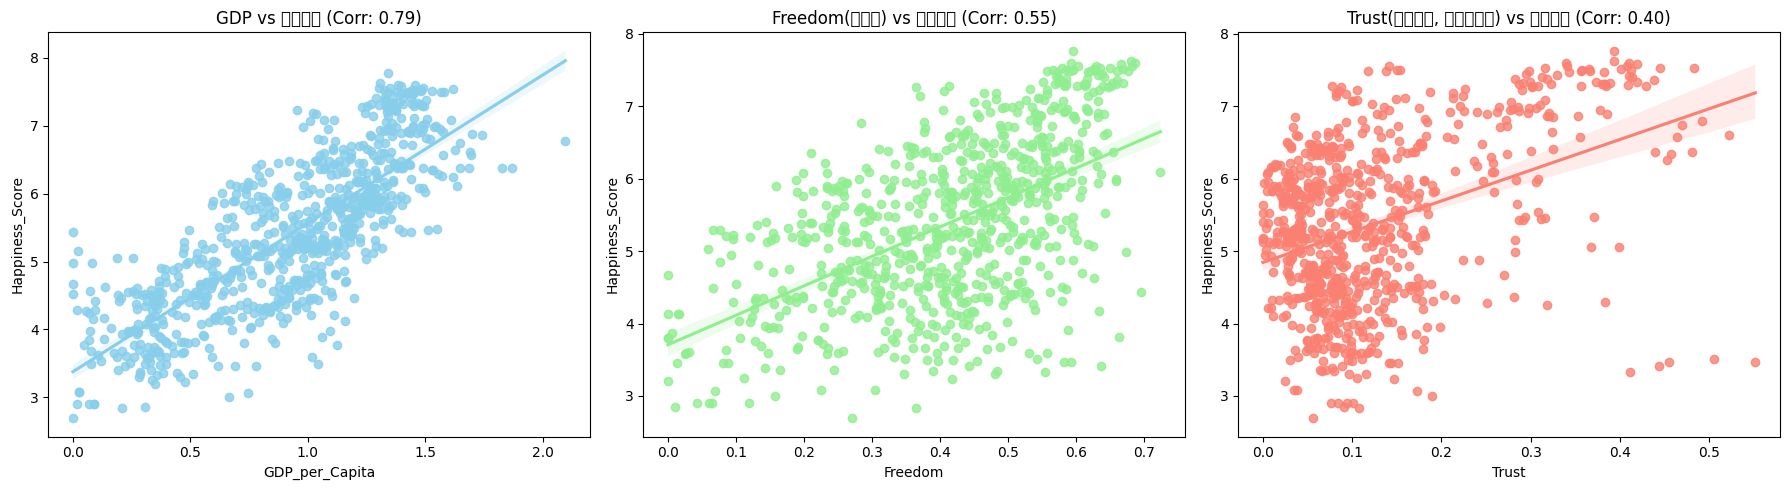

In [7]:
#그래프 레이아웃 설정
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#1. GDP vs 행복지수
sns.regplot(data=df_all, x='GDP_per_Capita', y='Happiness_Score', ax=axes[0], color='skyblue')
axes[0].set_title('GDP vs 행복지수 (Corr: 0.79)')

#2. Freedom(자유도) vs 행복지수
sns.regplot(data=df_all, x='Freedom', y='Happiness_Score', ax=axes[1], color='lightgreen')
axes[1].set_title('Freedom(자유도) vs 행복지수 (Corr: 0.55)')

#3. Trust(부패인식, 국민신뢰도) vs 행복지수
sns.regplot(data=df_all, x='Trust', y='Happiness_Score', ax=axes[2], color='salmon')
axes[2].set_title('Trust(부패인식, 국민신뢰도) vs 행복지수 (Corr: 0.40)')

plt.tight_layout()
plt.show() # 강한 상관관계일수록 직선에 점들이 모여있는 형태

#### 5년 연속 Top 10 국가의 행복지수 변화 추이

5년 연속 Top 10 유지 국가: {'Iceland', 'Finland', 'New Zealand', 'Netherlands', 'Denmark', 'Sweden', 'Canada', 'Switzerland', 'Norway'}


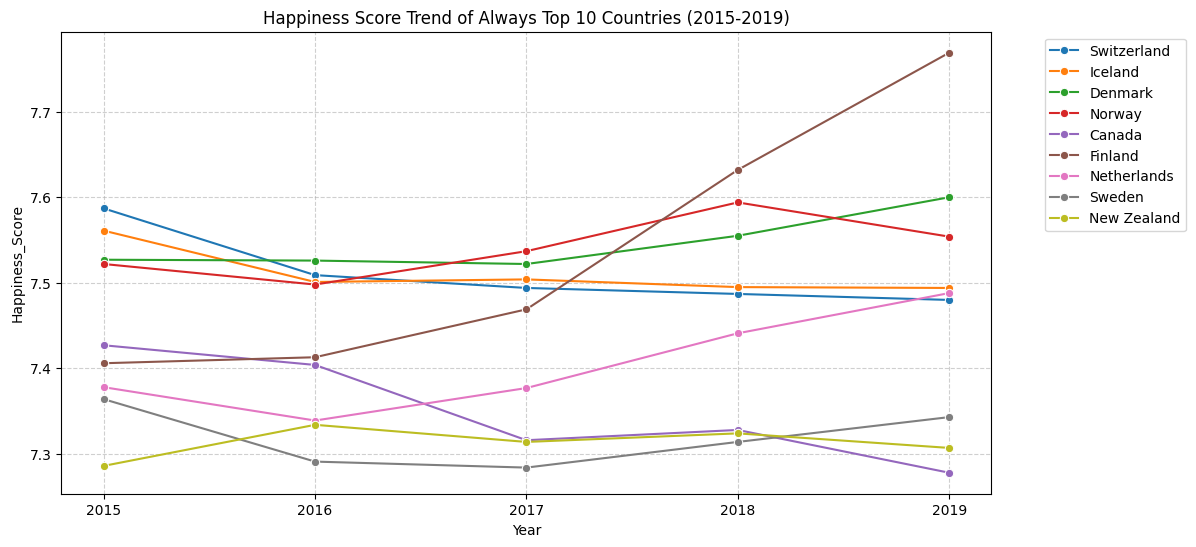

In [9]:
#각 연도별 Top 10 국가 리스트 추출
top10 = df_all[df_all['Happiness_Rank'] <= 10].groupby('Year')['Country'].apply(list)

#5년 내내 Top 10에 포함된 국가
always_top10 = set(top10[2015]) & set(top10[2016]) & \
               set(top10[2017]) & set(top10[2018]) & \
               set(top10[2019])
print(f"5년 연속 Top 10 유지 국가: {always_top10}")

#Top 10 국가들만 필터링
df_top10 = df_all[df_all['Country'].isin(always_top10)]

#그래프
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_top10, x='Year', y='Happiness_Score', hue='Country', marker='o')
plt.title('Happiness Score Trend of Always Top 10 Countries (2015-2019)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') #범례 표시
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks([2015, 2016, 2017, 2018, 2019])
plt.show()